# `AA Workshop 10` — Coding Challenge

Complete the tasks below to practice implementing classification modeling from `W10_Neural_Networks.ipynb`.

Guidelines:
- Work in order. Run each cell after editing with Shift+Enter.
- Keep answers short; focus on making things work.
- If a step fails, read the error and fix it.

By the end you will have exercised:
- defining an architecture of a NN
- implementing a NN for a multi-class classification problem
- evaluating performance throughout the fitting process

## Task 1 - Employing a Neural Network to Classify Breast Cancer Cells

In the workshop notebook, you learned how to use the keras framework for both classifcation and regression prediction. The classification example we used was for a binary output (cancer cells being benign or malignant). Let's see how we can employ neural networks for multi-class classification. Do the following:

1. Use the `../data/iris.csv` dataset and preproccess it as usual.
2. Think of an architecture you would employ to enable multi-class classification. You can get some inspiration [here](https://keras.io/guides/sequential_model/).
3. Implement a pipeline that consists of the following:
    1. train the model on training data
    2. evaluate and visualize loss on a training and validation set throughout the fitting of the network
4. Use that pipeline to test different architectures / hyperparameters
5. Report final performance on the test set
6. Think about the model complexity vs. performance tradeoff - is the NN the best overall model?

In [28]:
import pandas as pd
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras import layers, ops
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [29]:
iris_df = pd.read_csv("../data/iris.csv", index_col=0)
iris_df.dropna(inplace=True)
display(iris_df.head(3))
print(iris_df['Species'].value_counts())

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
number,,,,,
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa


Species
versicolor    49
setosa        48
virginica     43
Name: count, dtype: int64


In [30]:
X = iris_df.drop(columns=["Species"])
y = LabelEncoder().fit_transform(iris_df["Species"])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
print(X_train_scaled.shape)

(98, 4)


In [31]:
model = keras.Sequential(
    [
        layers.InputLayer(shape=(4,)),
        layers.Dense(2, activation="relu", name="layer1"),
        layers.Dense(3, activation="relu", name="layer2"),
        layers.Dense(4, name="layer3"),
        layers.Dense(3, activation='softmax')
    ],
    name="Iris_Classification_Model"
)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "Iris_Classification_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50 (200.00 B)

 Trainable params: 50 (200.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6531 - loss: 1.0574 - val_accuracy: 0.6905 - val_loss: 1.0356
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6531 - loss: 1.0525 - val_accuracy: 0.6905 - val_loss: 1.0315
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6531 - loss: 1.0476 - val_accuracy: 0.6905 - val_loss: 1.0273
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6531 - loss: 1.0428 - val_accuracy: 0.6905 - val_loss: 1.0230
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6531 - loss: 1.0378 - val_accuracy: 0.6905 - val_loss: 1.0185
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6531 - loss: 1.0326 - val_accuracy: 0.6905 - val_loss: 1.0138
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6531 - loss: 1.0273 - val_accuracy: 0.6905 - val_loss: 1.0090
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6531 - loss: 1.0217 - val_accuracy: 0.6905 - val_loss: 1.0042


<Axes: >

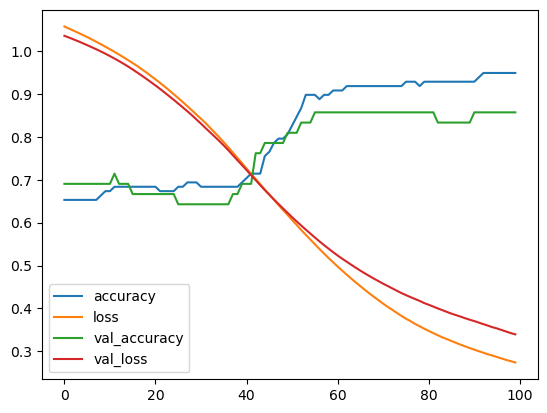

In [57]:
model = keras.Sequential(
    [
        layers.InputLayer(shape=(4,)),
        layers.Dense(2, activation="relu", name="layer1"),
        layers.Dense(3, activation="relu", name="layer2"),
        layers.Dense(4, name="layer3"),
        layers.Dense(3, activation='softmax')
    ],
    name="Iris_Classification_Model"
)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist = model.fit(
    X_train_scaled,
    y_train,
    batch_size=20,
    epochs=100,
    validation_data=(X_val_scaled, y_val),
)

pd.DataFrame(hist.history).plot()

In [63]:
print("Evaluation on test data:")
print("Accuracy: ", model.evaluate(X_val_scaled, y_val, verbose=0)[1])

Evaluation on test data:
Accuracy:  0.8571428656578064
